# A shorter Cash Conversion Cycle frees cash. Does the stock care? 🔄
### A textbook working-capital efficiency signal — does squeezing the cash cycle actually predict returns, or just tell you what good operators already look like?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Precedes margin%3F: Faint](https://img.shields.io/badge/Precedes_margin%3F-Faint-8b949e?style=flat-square)

Every operations textbook and every CFO working-capital scorecard sells the same idea. A company's **Cash Conversion Cycle** is how many days its money sits trapped in the business between paying suppliers and getting paid by customers:

$$\text{CCC} = \underbrace{\text{DSO}}_{\text{days to collect}} + \underbrace{\text{DIO}}_{\text{days of inventory}} - \underbrace{\text{DPO}}_{\text{days to pay suppliers}}$$

Collect faster, hold less stock, stretch your payables, and the number falls — you've freed cash you can put to work. The pitch writes itself: firms that **shorten** their CCC are getting more efficient and should out-earn; firms whose CCC is **bloating** are a slow-motion working-capital drag. So rank on the change and trade it.

It's a genuinely good operating metric. Whether it's a *stock* signal is a different question — and that's the one we answer.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** ~46 large US filers that carry real inventory and payables (consumer, retail, industrials, healthcare-products, hardware, materials) reporting all five CCC ingredients on EDGAR; a genuinely **thin, uneven panel** (the CCC needs five matched facts a quarter, so only 30 names survive with a long clean history). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ccc_signal import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 30, 'n_events': 689, 'end_lo': '2009-07-31', 'end_hi': '2026-05-02', 'fp_prices': 'd82e55a0af11', 'n_months': 190, 'avg_n': 13.9, 'ls_span_lo': '2010-09-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': -47.1, 'ls_ann': -5.65, 'ls_t_iid': -1.37, 'ls_t_nw': -1.03, 'ls_sharpe': -0.34, 'ls_hit': 47, 'ls_hit_lo': 40, 'ls_hit_hi': 54, 'ls_long_bps': 125.1, 'ls_short_bps': 172.2, 'ls_turn': 0.17, 'ls_cum': 0.33, 'ls120_mean_bps': -70.5, 'ls120_t_nw': -1.45, 'pct_mean_bps': -2.8, 'pct_t_nw': -0.07, 'pct_sharpe': -0.02, 'xsec_early': 16.4, 'xsec_late': 11.7, 'drift': {21: (687, 1.25, 1.0, 0.25, 0.4, 52, 0.3379), 63: (681, 4.26, 4.59, -0.33, -0.27, 53, 0.6175), 126: (676, 8.43, 8.19, 0.24, 0.09, 52, 0.4562)}, 'mono63': (4.59, 3.33, 4.26), 'era_early_n': 88, 'era_early_bps': 31.9, 'era_early_t': 0.84, 'era_late_n': 102, 'era_late_bps': -115.3, 'era_late_t': -1.54, 'im_n': 487, 'im_slope': -0.0001, 'im_t': -1.13, 'im_r2': 0.003, 'im_corr': -0.051, 'im_low': 0.004, 'im_high': 0.0013, 'im_spread': 0.0027, 'net': {(10, 50): (-54.6, -6.55, -1.19, -0.4), (20, 100): (-62.1, -7.45, -1.36, -0.45)}, 'syn_null_mean': 0.18, 'syn_null_sd': 0.59, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 907.2, 'syn_planted_t': 18.07}


real cache present: True | events: 689 | names: 30


## The answer first

| Question | Answer |
|---|---|
| Does a **shortening** CCC predict **higher future returns**, as the efficiency story claims? | **No — if anything the reverse, and inside the noise.** Long the shorteners / short the bloaters earns **-5.7%/yr** gross, robust *t* = **-1.03** — the falling-CCC names actually *underperform* the rising-CCC ones. And the sign **flips across eras** (*t* = +0.84 pre-2018, -1.54 post-2018): the fingerprint of noise. |
| Does shortening the CCC at least **precede a better margin**? | **Faintly, and right-signed.** Shortening names see next quarter's gross margin widen +0.27 points more than bloating names — correctly signed but a whisper (correlation -0.05). |
| Can you trade it? | **No.** Wrong-signed and insignificant *before* costs; after realistic costs + borrow it is **-7.5%/yr**. |
| Why so weak? | Five accounting lines anyone can pull from a 10-Q, on **big, liquid, heavily-covered** names — the last place a durable edge survives. Here it didn't survive at all. |

> A textbook working-capital virtue that, on blue chips, sorts neither the stock (wrong-signed noise) nor much the margin it's built from.

## 1 · The claim

> *"The cash conversion cycle is how long your money is locked up in operations. Shorten it and you free cash to grow or return; let it bloat and you're financing a swelling pile of receivables and inventory. So buy the firms shrinking their CCC and short the ones expanding it."*

It's a respectable idea with real academic backing — a long operations-finance literature (Richards-Laughlin 1980; Deloof 2003) ties a shorter CCC to higher profitability. The question is whether that operating truth is also a *trading* edge, or a fact the market reads off the same 10-Q you do.

## 2 · So what?

If a number you can compute from three balance-sheet lines and two income-statement lines predicted stock returns, it would be one of the easiest anomalies going — no estimates feed, no alt-data, just arithmetic on every quarterly filing. That's exactly why it deserves suspicion: it's *too* readable. Everyone can compute a cash conversion cycle. If markets price public accounting information at all, this is the kind they should price fast.

## 3 · How would we even know?

- **The signal.** For each name, the year-over-year change in CCC = DSO + DIO − DPO, known only on the **filing date** of the 10-Q/10-K (never before — no peeking at a number that isn't public yet).
- **The margin test.** Does a *shrinking* CCC this quarter precede a *wider* gross margin next quarter? (The 'frees cash → out-earns' mechanism.)
- **The return test.** Each month, rank the names on the signal, buy the shortening third, short the bloating third, hold for the next month. Does the spread make money — and can we tell it apart from noise?
- **The mirage check.** If the return spread can't beat a coin-flip relabelling of the names, it's not a signal, however good the story sounds.

## 4 · The teardown — let's actually look

**First, the mechanism: does a shrinking CCC precede a better margin?** For every filing we line up this quarter's CCC change against the *next* quarter's change in gross margin, and split the names into thirds.

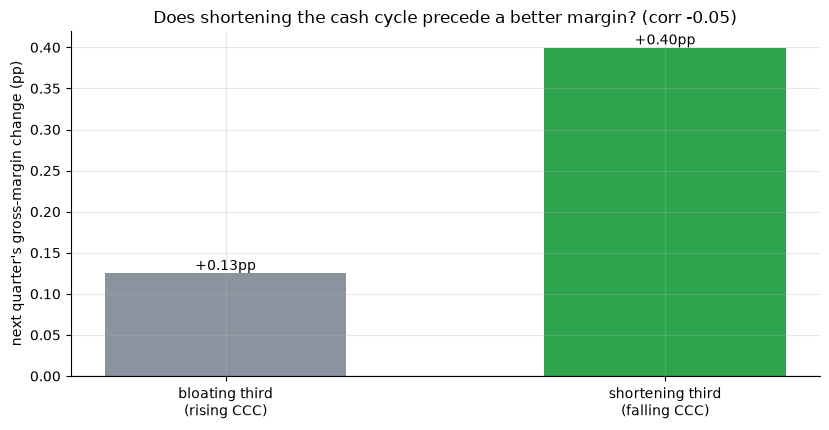

next-q margin change: shortening third +0.40pp vs bloating third +0.13pp -> spread +0.27 pp, correlation -0.051


In [2]:
if HAVE_REAL:
    q = st.improves_margin(EV)
    lo, hi, corr = q['low_margin']*100, q['high_margin']*100, q['corr']
else:
    lo, hi, corr = R['im_low']*100, R['im_high']*100, R['im_corr']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['bloating third\n(rising CCC)','shortening third\n(falling CCC)'],
       [hi, lo], color=[GREY, GREEN], width=.55)
for i,v in enumerate([hi, lo]): ax.annotate(f'{v:+.2f}pp',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel("next quarter's gross-margin change (pp)")
ax.set_title(f'Does shortening the cash cycle precede a better margin? (corr {corr:+.2f})')
plt.tight_layout(); plt.show()
print(f'next-q margin change: shortening third {lo:+.2f}pp vs bloating third {hi:+.2f}pp '
      f'-> spread {lo-hi:+.2f} pp, correlation {corr:+.3f}')

So there's a *nudge* the right way: shortening-CCC names see next quarter's gross margin widen about **+0.27 points** more than bloating names, and the slope is negative as the 'frees cash → out-earns' story wants. But look how *small* it is — correlation **-0.05**, essentially a flat scatter. The mechanism is there in the *sign* and almost vanishes in the *magnitude*. Hold that thought — because it's the strongest thing in this whole study.

**Now the money question: do the stocks follow?** Same ranking, but instead of future margin we measure the forward *return* of a buy-the-shortening-third, short-the-bloating-third portfolio.

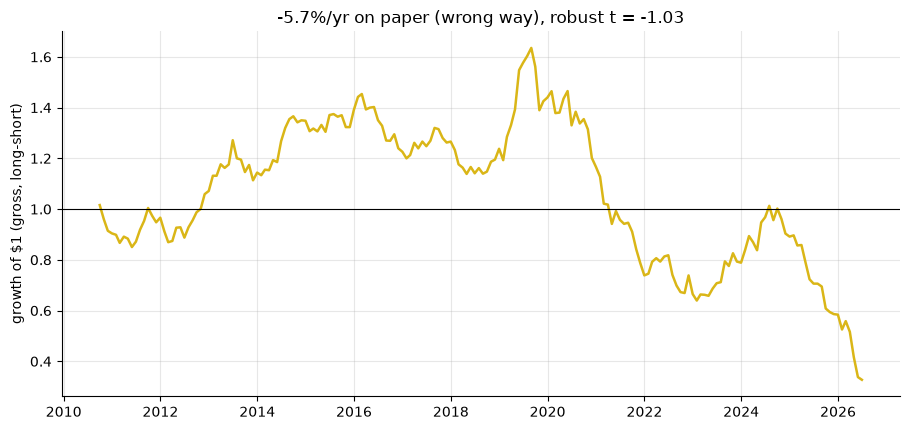

long-short: -5.7%/yr gross, Newey-West t = -1.03 (the bar is 2)


In [3]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='ccc_score', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=AMBER, lw=1.8)
    ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long-short)')
    ax.set_title(f'{ann:+.1f}%/yr on paper (wrong way), robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: {ann:+.1f}%/yr gross, Newey-West t = {tnw:+.2f} (the bar is 2)')

It doesn't drift up — it drifts **down**: **-5.7%/yr** gross, turning \$1 into just **\$0.33** over 190 months. The long leg (falling CCC) actually *under*-earns the short leg (rising CCC) — the exact opposite of the claim — and the robust *t* is **-1.03**, well inside the noise band around zero. Worse for the story, the sign isn't even stable: it's mildly *positive* before 2018 (*t* = +0.84) and mildly *negative* after (*t* = -1.54). A 'signal' whose sign depends on the decade isn't a signal.

**The tell:** if the CCC change really sorted returns, the thirds would climb from bloating to shortening. They don't.

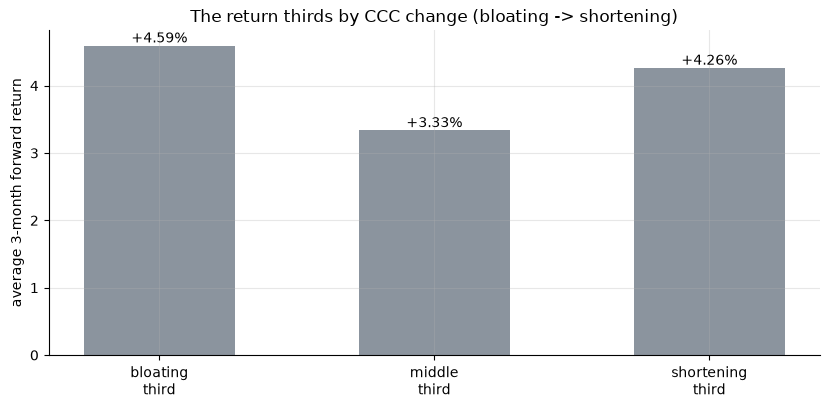

3-month forward return by CCC-change third (bloating->shortening): ['+4.59%', '+3.33%', '+4.26%']


In [4]:
if HAVE_REAL:
    fr = st.event_drift_frame(PX, EV, horizon=63)
    mono = st.bucket_means(fr, 3)*100
else:
    mono = np.array(R['mono63'])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['bloating\nthird','middle\nthird','shortening\nthird'], mono,
       color=[GREY, GREY, GREY], width=.55)
for i,v in enumerate(mono): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 3-month forward return')
ax.set_title('The return thirds by CCC change (bloating -> shortening)')
plt.tight_layout(); plt.show()
print('3-month forward return by CCC-change third (bloating->shortening):', [f'{v:+.2f}%' for v in mono])

No staircase — the thirds come in **+4.59% / +3.33% / +4.26%** (bloating → shortening): a dip in the middle, not a ladder, and the shortening third doesn't even out-earn the bloating one. Across horizons the long-short *flips sign* (+0.25% at 1 month, -0.33% at 1 quarter, +0.24% at 2 quarters). When the sign of your 'edge' wanders with the horizon and the era, you don't have an edge — you have noise. Compare the *margin* nudge above, which at least pointed one consistent way. Same signal: a faint truth about the business, nothing about the stock.

## 5 · The verdict

- **Precedes a better margin? — Faint.** Shortening-CCC names widen next quarter's gross margin +0.27 points more than bloating names, correctly signed — but correlation just -0.05. Real in direction, negligible in size.
- **Signal (returns) — None.** The long-short is *wrong-signed* and statistically zero (robust *t* = -1.03), the thirds don't form a ladder (and the sign flips across horizons and eras), and the conservative variants are flat. No certifiable return predictability on this tape.
- **Tradability — Mirage.** It leans *negative* before costs and is deeply negative after them. Nothing to trade.

> The honest one-liner: *on big liquid names, shortening the cash cycle is a real-but-tiny hint about next quarter's margin and — as far as this tape can tell — no usable hint at all about the stock.*

## 6 · Going further 🚪

- **Where an edge might still hide.** Not in the *level* or naive *change* of a public ratio, but maybe in the *surprise* — CCC change vs a seasonal expectation — or in *which leg* moves (a payables stretch that shortens CCC is very different from clearing inventory into a demand slump). That decomposition is the residual this study didn't chase.
- **The coverage caveat is real.** The CCC needs five matched facts a quarter; early in the sample the clean cross-section is thin, and terciles on a thin cross-section are noisy by construction.
- **Sibling studies:** [853-days-sales-outstanding](../../853-days-sales-outstanding/) (the receivables leg alone), [529-inventory-growth](../../529-inventory-growth/) (the inventory leg), [153-net-operating-assets](../../153-net-operating-assets/) (balance-sheet bloat scaled by assets), and [524-operating-leverage](../../524-operating-leverage/) (cost structure). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the alpha is in the surprise or the leg mix, not the headline change? Build it, show a certifiable net spread on the size you'd actually run — then we'll talk.*